# Updated plate v3 near-completion shrinkage

Use a complete sparse Cholesky basis and its last `n-m` omitted directions to evaluate the v3 operation: take the coordinate hull first, then intersect it with the primary initial box (`box_1`). Only the requested all-coordinate shrinkage percentages and histogram are retained.

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig")

from pathlib import Path
import gc

import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse import diags, load_npz
from scipy.sparse.csgraph import reverse_cuthill_mckee
from scipy.sparse.linalg import splu, spsolve_triangular


data_dir = Path("system_updated_plate")
A = load_npz(data_dir / "A.npz").tocsr()
b = np.loadtxt(data_dir / "b.dat", dtype=float)
stored_solution = np.loadtxt(data_dir / "soln_x.dat", dtype=float)
initial_box = np.loadtxt(data_dir / "box_1.dat", dtype=float)

n = b.size
if A.shape != (n, n) or initial_box.shape != (n, 2):
    raise ValueError("Updated-plate matrix, right-hand side, or box has an unexpected shape.")
if np.any(initial_box[:, 0] > initial_box[:, 1]):
    raise ValueError("box_1 contains inverted intervals.")

diagonal = A.diagonal()
if np.any(diagonal <= 0.0):
    raise ValueError("Jacobi scaling requires a positive diagonal.")
scale = np.sqrt(diagonal)
inverse_scale = 1.0 / scale
A_hat = (diags(inverse_scale) @ A @ diags(inverse_scale)).tocsr()
b_hat = inverse_scale * b

# Reordering controls fill without changing the Cholesky-tail construction.
permutation = reverse_cuthill_mckee(A_hat, symmetric_mode=True)
A_permuted = A_hat[permutation][:, permutation].tocsc()
factor = splu(
    A_permuted, permc_spec="NATURAL", diag_pivot_thresh=0.0,
    options={"SymmetricMode": True},
)
identity_permutation = np.arange(n)
if not (np.array_equal(factor.perm_r, identity_permutation) and
        np.array_equal(factor.perm_c, identity_permutation)):
    raise RuntimeError("The SPD factorization unexpectedly introduced pivot permutations.")

# For an SPD matrix without pivoting, U = D L.T and C = L sqrt(D) is Cholesky.
d_factor = factor.U.diagonal()
if np.any(d_factor <= 0.0):
    raise RuntimeError("The factorization has a nonpositive Cholesky pivot.")
factor_difference = factor.U - diags(d_factor) @ factor.L.T
factor_relation_error = (
    float(np.max(np.abs(factor_difference.data))) if factor_difference.nnz else 0.0
)
if factor_relation_error > 1.0e-12:
    raise RuntimeError("Sparse factors do not satisfy the expected LDL.T relation.")
del factor_difference, A_permuted
gc.collect()

y_star = factor.solve(b_hat[permutation])
x_star = np.empty(n, dtype=float)
x_star[permutation] = y_star / scale[permutation]
outside_original_box = (x_star < initial_box[:, 0]) | (x_star > initial_box[:, 1])
effective_box = np.column_stack([
    np.minimum(initial_box[:, 0], x_star),
    np.maximum(initial_box[:, 1], x_star),
])
effective_box_permuted = effective_box[permutation]
scale_permuted = scale[permutation]
lower0 = scale_permuted * effective_box_permuted[:, 0]
upper0 = scale_permuted * effective_box_permuted[:, 1]
center0 = 0.5 * (lower0 + upper0)
radius0 = 0.5 * (upper0 - lower0)
if np.any(radius0 <= 0.0):
    raise ValueError("The effective box must have positive width in every coordinate.")

print(f"system dimension n: {n:,}")
print(f"matrix nonzeros: {A.nnz:,}")
print(f"independent Cholesky directions: {np.count_nonzero(d_factor > 0):,}")
print(f"max |U - D L.T|: {factor_relation_error:.3e}")
print(f"stored/computed solution max difference: {np.max(np.abs(stored_solution - x_star)):.3e}")
print(f"coordinates expanded to contain the solution: {outside_original_box.sum():,}")

system dimension n: 21,570
matrix nonzeros: 659,988
independent Cholesky directions: 21,570
max |U - D L.T|: 3.331e-16
stored/computed solution max difference: 1.835e-12
coordinates expanded to contain the solution: 0


In [2]:
omitted_counts = np.arange(0, 1201, 150, dtype=int)
m_values = n - omitted_counts
max_omitted = int(omitted_counts[-1])
tail_start = n - max_omitted
sqrt_d = np.sqrt(d_factor)

# P = C^{-T}. Only its final 1,200 columns are needed. Since C = L sqrt(D),
# solve L.T P = sqrt(D)^{-1} E_tail using all right-hand sides together.
tail_rhs = np.zeros((n, max_omitted), dtype=float, order="F")
tail_indices = np.arange(tail_start, n)
tail_rhs[tail_indices, np.arange(max_omitted)] = 1.0 / sqrt_d[tail_indices]
P_tail = spsolve_triangular(
    factor.L.T.tocsr(), tail_rhs, lower=False, unit_diagonal=True,
    overwrite_A=True, overwrite_b=True,
)
del tail_rhs
gc.collect()

initial_width = upper0 - lower0
shrinkage_permuted = np.empty((len(omitted_counts), n), dtype=float)
row_block_size = 256
for row, omitted in enumerate(omitted_counts):
    if omitted == 0:
        shrinkage_permuted[row] = 100.0
        continue

    start = n - int(omitted)
    P = P_tail[:, max_omitted - omitted:]
    L_tail = factor.L[start:, start:].tocsr()
    sqrt_d_tail = sqrt_d[start:]
    center_delta_tail = center0[start:] - y_star[start:]
    radius_tail = radius0[start:]

    for block_start in range(0, n, row_block_size):
        block_stop = min(block_start + row_block_size, n)
        P_block = P[block_start:block_stop]
        # Pi_tail = P C_tail.T, with C_tail = L_tail sqrt(D_tail).
        Pi_block = (L_tail @ (P_block * sqrt_d_tail).T).T
        projected_center = (
            y_star[block_start:block_stop] + Pi_block @ center_delta_tail
        )
        projected_radius = np.abs(Pi_block) @ radius_tail
        lower = np.maximum(
            lower0[block_start:block_stop], projected_center - projected_radius
        )
        upper = np.minimum(
            upper0[block_start:block_stop], projected_center + projected_radius
        )
        if np.any(lower > upper):
            raise RuntimeError("Roundoff produced an empty coordinate intersection.")
        shrinkage_permuted[row, block_start:block_stop] = np.clip(
            100.0 * (1.0 - (upper - lower) / initial_width[block_start:block_stop]),
            0.0, 100.0,
        )

if not np.all(shrinkage_permuted[0] == 100.0):
    raise AssertionError("The m=n enclosure did not contract to degeneracy.")

# Restore original coordinate order in the saved all-coordinate result.
shrinkage_pct = np.empty_like(shrinkage_permuted)
shrinkage_pct[:, permutation] = shrinkage_permuted
quantile_levels = np.array([0.0, 0.10, 0.25, 0.50, 0.75, 0.90, 1.0])
quantiles = np.quantile(shrinkage_pct, quantile_levels, axis=1).T
print("Shrinkage across all coordinates (%)")
print("m       omitted    mean    median     min     p10     p90     max")
for m, omitted, values, qs in zip(m_values, omitted_counts, shrinkage_pct, quantiles):
    print(
        f"{m:5d}   {omitted:7d}   {values.mean():6.2f}   {np.median(values):6.2f}"
        f"   {qs[0]:6.2f}  {qs[1]:6.2f}  {qs[5]:6.2f}  {qs[6]:6.2f}"
    )

results_dir = Path("system_updated_plate_to_completion_results")
results_dir.mkdir(exist_ok=True)
np.savez_compressed(
    results_dir / "v3_shrinkage_percentages.npz",
    n=n, m_values=m_values, omitted_counts=omitted_counts,
    shrinkage_pct=shrinkage_pct,
    expanded_coordinate_count=outside_original_box.sum(),
    box_name="box_1", permutation=permutation,
)

Shrinkage across all coordinates (%)
m       omitted    mean    median     min     p10     p90     max
21570         0   100.00   100.00   100.00  100.00  100.00  100.00
21420       150    45.71     0.00     0.00    0.00   97.39   99.44
21270       300    43.89     0.00     0.00    0.00   95.75   98.72
21120       450    42.22     0.00     0.00    0.00   94.16   97.96
20970       600    39.00     0.00     0.00    0.00   90.93   96.68
20820       750    38.46     0.00     0.00    0.00   90.23   96.09
20670       900    37.90     0.00     0.00    0.00   89.55   95.70
20520      1050    35.94     0.00     0.00    0.00   87.27   94.78
20370      1200    35.98     0.00     0.00    0.00   87.17   94.47


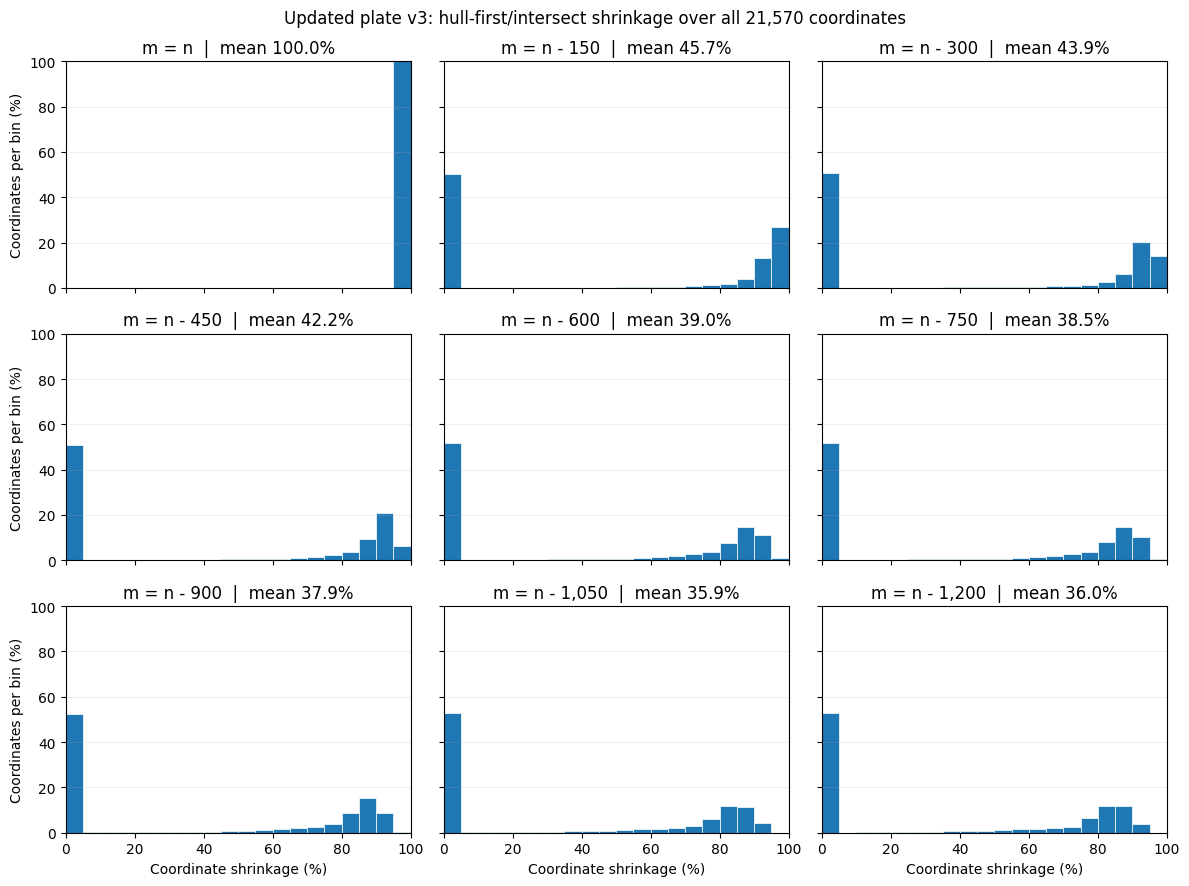

saved system_updated_plate_to_completion_results/v3_shrinkage_histogram.png


In [3]:
bins = np.linspace(0.0, 100.0, 21)
fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True, sharey=True)
for ax, m, omitted, values in zip(axes.ravel(), m_values, omitted_counts, shrinkage_pct):
    ax.hist(
        values, bins=bins, weights=np.full(n, 100.0 / n),
        color="tab:blue", edgecolor="white", linewidth=0.5,
    )
    label = "m = n" if omitted == 0 else f"m = n - {omitted:,}"
    ax.set_title(f"{label}  |  mean {values.mean():.1f}%")
    ax.grid(axis="y", alpha=0.2)

for ax in axes[-1, :]:
    ax.set_xlabel("Coordinate shrinkage (%)")
for ax in axes[:, 0]:
    ax.set_ylabel("Coordinates per bin (%)")
for ax in axes.ravel():
    ax.set_xlim(0.0, 100.0)
    ax.set_ylim(0.0, 100.0)

fig.suptitle(f"Updated plate v3: hull-first/intersect shrinkage over all {n:,} coordinates")
fig.tight_layout()
figure_path = results_dir / "v3_shrinkage_histogram.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"saved {figure_path}")